<a href="https://colab.research.google.com/github/Kriti-2180/Deep-Learning/blob/main/SGD_vs_Momentum_Optimizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers

In [10]:
np.random.seed(42)

X = np.random.rand(1000, 1)
y = 3 * X + np.random.randn(1000, 1) * 0.1

In [11]:
X_train, X_test = X[:800], X[800:]
y_train, y_test = y[:800], y[800:]

In [12]:
def build_model():
    model = keras.Sequential([
        layers.Dense(10, activation='relu', input_shape=(1,)),
        layers.Dense(1)
    ])
    return model

In [13]:
model_sgd = build_model()

sgd = keras.optimizers.SGD(learning_rate=0.01)

model_sgd.compile(
    optimizer=sgd,
    loss='mse'
)

history_sgd = model_sgd.fit(
    X_train, y_train,
    epochs=50,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 1.8294 - val_loss: 0.7273
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5784 - val_loss: 0.4259
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4038 - val_loss: 0.3762
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3518 - val_loss: 0.3351
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3086 - val_loss: 0.2942
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2681 - val_loss: 0.2554
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2295 - val_loss: 0.2168
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1937 - val_loss: 0.1830
Epoch 9/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1610 - val_loss: 0.1507
Epoch 10/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1322 - val_loss: 0.1246
Epoch 11/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1072 - val_loss: 0.1005
Epoch 12/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0860 - val_l

In [14]:
model_momentum = build_model()

momentum_optimizer = keras.optimizers.SGD(
    learning_rate=0.01,
    momentum=0.9
)

model_momentum.compile(
    optimizer=momentum_optimizer,
    loss='mse'
)

history_momentum = model_momentum.fit(
    X_train, y_train,
    epochs=50,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.5854 - val_loss: 0.2135
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0808 - val_loss: 0.0160
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0132 - val_loss: 0.0111
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0109 - val_loss: 0.0106
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0103 - val_loss: 0.0104
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0103 - val_loss: 0.0101
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0102 - val_loss: 0.0100
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0101 - val_loss: 0.0099
Epoch 9/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0100 - val_loss: 0.0100
Epoch 10/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0100 - val_loss: 0.0098
Epoch 11/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0100 - val_loss: 0.0097
Epoch 12/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0101 - val_l

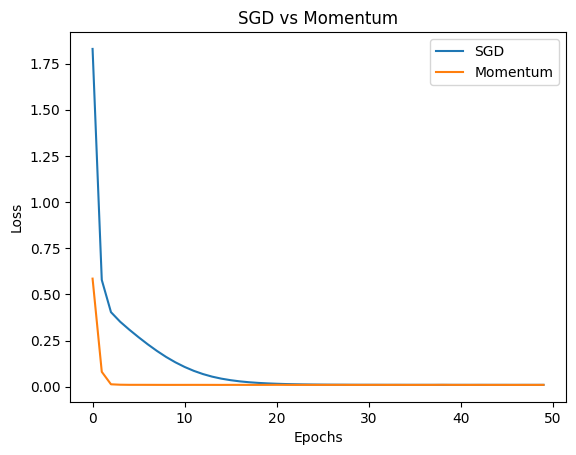

In [15]:
plt.plot(history_sgd.history['loss'], label='SGD')
plt.plot(history_momentum.history['loss'], label='Momentum')

plt.title("SGD vs Momentum")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [16]:
print("SGD Loss:", model_sgd.evaluate(X_test, y_test, verbose=0))
print("Momentum Loss:", model_momentum.evaluate(X_test, y_test, verbose=0))

SGD Loss: 0.010156427510082722
Momentum Loss: 0.009679489769041538
